<img src="https://webna.ir/wp-content/uploads/2018/08/%D9%85%DA%A9%D8%AA%D8%A8-%D8%AE%D9%88%D9%86%D9%87.png" width=50% />

<div class="alert alert-block alert-success">
    <h1 align="center">Machine Learning in Python</h1>
    <h3 align="center">Mini Project1</h3>
</div>

<img src = "https://www.cyclonis.com/images/2020/03/googleplay.jpg" width=50%>

## Importing the libraries

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings("ignore")

## Load and Prepare Data

In [2]:
data = pd.read_csv("googleplaystore.csv")

In [3]:
data.drop(data[data["Rating"]==19].index,inplace = True)

In [4]:
data["Installs"] = data["Installs"].apply(lambda x:x.replace("+","").replace(",","").replace("Free", "0")).astype("int64")

In [5]:
data["Price"] = data["Price"].apply(lambda x:x.replace("$","").replace("Everyone","0")).astype("float16")

In [6]:
data["Reviews"] = data["Reviews"].astype("int64")

In [7]:
pd.set_option('display.float_format', '{:.2f}'.format)

## EDA

In [8]:
data.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.10,159,19M,10000,Free,0.00,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.90,967,14M,500000,Free,0.00,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.70,87510,8.7M,5000000,Free,0.00,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.50,215644,25M,50000000,Free,0.00,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.30,967,2.8M,100000,Free,0.00,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [9]:
data.tail()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10836,Sya9a Maroc - FR,FAMILY,4.50,38,53M,5000,Free,0.00,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.00,4,3.6M,100,Free,0.00,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,1000,Free,0.00,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.50,114,Varies with device,1000,Free,0.00,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device
10840,iHoroscope - 2018 Daily Horoscope & Astrology,LIFESTYLE,4.50,398307,19M,10000000,Free,0.00,Everyone,Lifestyle,"July 25, 2018",Varies with device,Varies with device


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int64  
 4   Size            10840 non-null  object 
 5   Installs        10840 non-null  int64  
 6   Type            10839 non-null  object 
 7   Price           10840 non-null  float16
 8   Content Rating  10840 non-null  object 
 9   Genres          10840 non-null  object 
 10  Last Updated    10840 non-null  object 
 11  Current Ver     10832 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float16(1), float64(1), int64(2), object(9)
memory usage: 1.1+ MB


In [11]:
data.describe()

,Rating,Reviews,Installs,Price
count,9366.00,10840.00,10840.00,10840.00
mean,4.19,444152.90,15464338.88,1.03
std,0.52,2927760.60,85029361.40,inf
min,1.00,0.00,0.00,0.00
25%,4.00,38.00,1000.00,0.00
50%,4.30,2094.00,100000.00,0.00
75%,4.50,54775.50,5000000.00,0.00
max,5.00,78158306.00,1000000000.00,400.00


In [12]:
data[["Rating","Category","Installs"]].groupby("Category").mean().reset_index()

,Category,Rating,Installs
0,ART_AND_DESIGN,4.36,1912893.85
1,AUTO_AND_VEHICLES,4.19,625061.31
2,BEAUTY,4.28,513151.89
3,BOOKS_AND_REFERENCE,4.35,8318050.11
4,BUSINESS,4.12,2178075.79
5,COMICS,4.16,934769.17
6,COMMUNICATION,4.16,84359886.95
7,DATING,3.97,1129533.36
8,EDUCATION,4.39,5586230.77
9,ENTERTAINMENT,4.13,19256107.38


In [13]:
data["Category"].value_counts()

Category
FAMILY                 1972
GAME                   1144
TOOLS                   843
MEDICAL                 463
BUSINESS                460
PRODUCTIVITY            424
PERSONALIZATION         392
COMMUNICATION           387
SPORTS                  384
LIFESTYLE               382
FINANCE                 366
HEALTH_AND_FITNESS      341
PHOTOGRAPHY             335
SOCIAL                  295
NEWS_AND_MAGAZINES      283
SHOPPING                260
TRAVEL_AND_LOCAL        258
DATING                  234
BOOKS_AND_REFERENCE     231
VIDEO_PLAYERS           175
EDUCATION               156
ENTERTAINMENT           149
MAPS_AND_NAVIGATION     137
FOOD_AND_DRINK          127
HOUSE_AND_HOME           88
AUTO_AND_VEHICLES        85
LIBRARIES_AND_DEMO       85
WEATHER                  82
ART_AND_DESIGN           65
EVENTS                   64
PARENTING                60
COMICS                   60
BEAUTY                   53
Name: count, dtype: int64

In [14]:
data[["Category","Installs"]].groupby("Category").sum().reset_index().sort_values(by="Installs",ascending=False)

,Category,Installs
14,GAME,35086024415
6,COMMUNICATION,32647276251
25,PRODUCTIVITY,14176091369
27,SOCIAL,14069867902
29,TOOLS,11452771915
11,FAMILY,10258263505
24,PHOTOGRAPHY,10088247655
21,NEWS_AND_MAGAZINES,7496317760
30,TRAVEL_AND_LOCAL,6868887146
31,VIDEO_PLAYERS,6222002720


In [15]:
data.drop_duplicates(subset="App").sort_values(by=["Installs","Rating"],ascending=False).head(10)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
1654,Subway Surfers,GAME,4.50,27722264,76M,1000000000,Free,0.00,Everyone 10+,Arcade,"July 12, 2018",1.90.0,4.1 and up
2545,Instagram,SOCIAL,4.50,66577313,Varies with device,1000000000,Free,0.00,Teen,Social,"July 31, 2018",Varies with device,Varies with device
2808,Google Photos,PHOTOGRAPHY,4.50,10858556,Varies with device,1000000000,Free,0.00,Everyone,Photography,"August 6, 2018",Varies with device,Varies with device
336,WhatsApp Messenger,COMMUNICATION,4.40,69119316,Varies with device,1000000000,Free,0.00,Everyone,Communication,"August 3, 2018",Varies with device,Varies with device
3234,Google,TOOLS,4.40,8033493,Varies with device,1000000000,Free,0.00,Everyone,Tools,"August 3, 2018",Varies with device,Varies with device
3454,Google Drive,PRODUCTIVITY,4.40,2731171,Varies with device,1000000000,Free,0.00,Everyone,Productivity,"August 6, 2018",Varies with device,Varies with device
338,Google Chrome: Fast & Secure,COMMUNICATION,4.30,9642995,Varies with device,1000000000,Free,0.00,Everyone,Communication,"August 1, 2018",Varies with device,Varies with device
340,Gmail,COMMUNICATION,4.30,4604324,Varies with device,1000000000,Free,0.00,Everyone,Communication,"August 2, 2018",Varies with device,Varies with device
865,Google Play Games,ENTERTAINMENT,4.30,7165362,Varies with device,1000000000,Free,0.00,Teen,Entertainment,"July 16, 2018",Varies with device,Varies with device
3117,Maps - Navigate & Explore,TRAVEL_AND_LOCAL,4.30,9235155,Varies with device,1000000000,Free,0.00,Everyone,Travel & Local,"July 31, 2018",Varies with device,Varies with device


In [16]:
data.drop_duplicates(subset="App")[data["Type"]=="Paid"].sort_values(by=["Installs","Rating"],ascending=False).head(10)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
4034,Hitman Sniper,GAME,4.60,408292,29M,10000000,Paid,0.99,Mature 17+,Action,"July 12, 2018",1.7.110758,4.1 and up
2241,Minecraft,FAMILY,4.50,2376564,Varies with device,10000000,Paid,6.99,Everyone 10+,Arcade;Action & Adventure,"July 24, 2018",1.5.2.1,Varies with device
9678,Where's My Water?,FAMILY,4.70,188740,69M,1000000,Paid,1.99,Everyone,Puzzle;Brain Games,"July 5, 2018",1.16.0,4.2 and up
4260,Cut the Rope GOLD,FAMILY,4.60,61264,43M,1000000,Paid,0.99,Everyone,Puzzle,"June 19, 2018",3.7.0,4.1 and up
5631,Five Nights at Freddy's,GAME,4.60,100805,50M,1000000,Paid,2.99,Teen,Action,"December 2, 2014",1.85,2.3 and up
8804,DraStic DS Emulator,GAME,4.60,87766,12M,1000000,Paid,4.99,Everyone,Action,"July 19, 2016",r2.5.0.3a,2.3 and up
8860,Bloons TD 5,FAMILY,4.60,190086,94M,1000000,Paid,2.99,Everyone,Strategy,"July 13, 2018",3.16,2.3.3 and up
9941,Tasker,TOOLS,4.60,43045,Varies with device,1000000,Paid,2.99,Everyone,Tools,"June 25, 2018",Varies with device,Varies with device
5578,Sleep as Android Unlock,LIFESTYLE,4.50,23966,872k,1000000,Paid,5.99,Everyone,Lifestyle,"June 27, 2018",20180608,4.0 and up
7355,Threema,COMMUNICATION,4.50,51110,Varies with device,1000000,Paid,2.99,Everyone,Communication,"August 3, 2018",Varies with device,Varies with device


In [17]:
data.drop_duplicates(subset="App")[data["Type"]=="Paid"].sort_values(by="Price",ascending=False).head(10)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
5373,I AM RICH PRO PLUS,FINANCE,4.00,36,41M,1000,Paid,400.00,Everyone,Finance,"June 25, 2018",1.0.2,4.1 and up
4362,💎 I'm rich,LIFESTYLE,3.80,718,26M,10000,Paid,400.00,Everyone,Lifestyle,"March 11, 2018",1.0.0,4.4 and up
5369,I am Rich,FINANCE,4.30,180,3.8M,5000,Paid,400.00,Everyone,Finance,"March 22, 2018",1.0,4.2 and up
5364,I am rich (Most expensive app),FINANCE,4.10,129,2.7M,1000,Paid,400.00,Teen,Finance,"December 6, 2017",2,4.0.3 and up
5362,I Am Rich Pro,FAMILY,4.40,201,2.7M,5000,Paid,400.00,Everyone,Entertainment,"May 30, 2017",1.54,1.6 and up
5359,I am rich(premium),FINANCE,3.50,472,965k,5000,Paid,400.00,Everyone,Finance,"May 1, 2017",3.4,4.4 and up
4197,most expensive app (H),FAMILY,4.30,6,1.5M,100,Paid,400.00,Everyone,Entertainment,"July 16, 2018",1.0,7.0 and up
5356,I Am Rich Premium,FINANCE,4.10,1867,4.7M,50000,Paid,400.00,Everyone,Finance,"November 12, 2017",1.6,4.0 and up
5354,I am Rich Plus,FAMILY,4.00,856,8.7M,10000,Paid,400.00,Everyone,Entertainment,"May 19, 2018",3.0,4.4 and up
5351,I am rich,LIFESTYLE,3.80,3547,1.8M,100000,Paid,400.00,Everyone,Lifestyle,"January 12, 2018",2.0,4.0.3 and up


## Data Preprocessing

In [18]:
data.isna().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
dtype: int64

In [19]:
data[data.Rating.isna()].value_counts("Category")

Category
FAMILY                 225
BUSINESS               157
MEDICAL                113
TOOLS                  109
PERSONALIZATION         78
PRODUCTIVITY            73
LIFESTYLE               68
SPORTS                  65
COMMUNICATION           59
BOOKS_AND_REFERENCE     53
NEWS_AND_MAGAZINES      50
GAME                    47
HEALTH_AND_FITNESS      44
FINANCE                 43
DATING                  39
SOCIAL                  36
TRAVEL_AND_LOCAL        32
SHOPPING                22
LIBRARIES_AND_DEMO      20
EVENTS                  19
FOOD_AND_DRINK          18
PHOTOGRAPHY             18
VIDEO_PLAYERS           15
MAPS_AND_NAVIGATION     13
HOUSE_AND_HOME          12
AUTO_AND_VEHICLES       12
BEAUTY                  11
PARENTING               10
WEATHER                  7
ART_AND_DESIGN           3
COMICS                   2
EDUCATION                1
Name: count, dtype: int64

## Strorytelling - Visualization

In [20]:
sns.set_style("darkgrid")

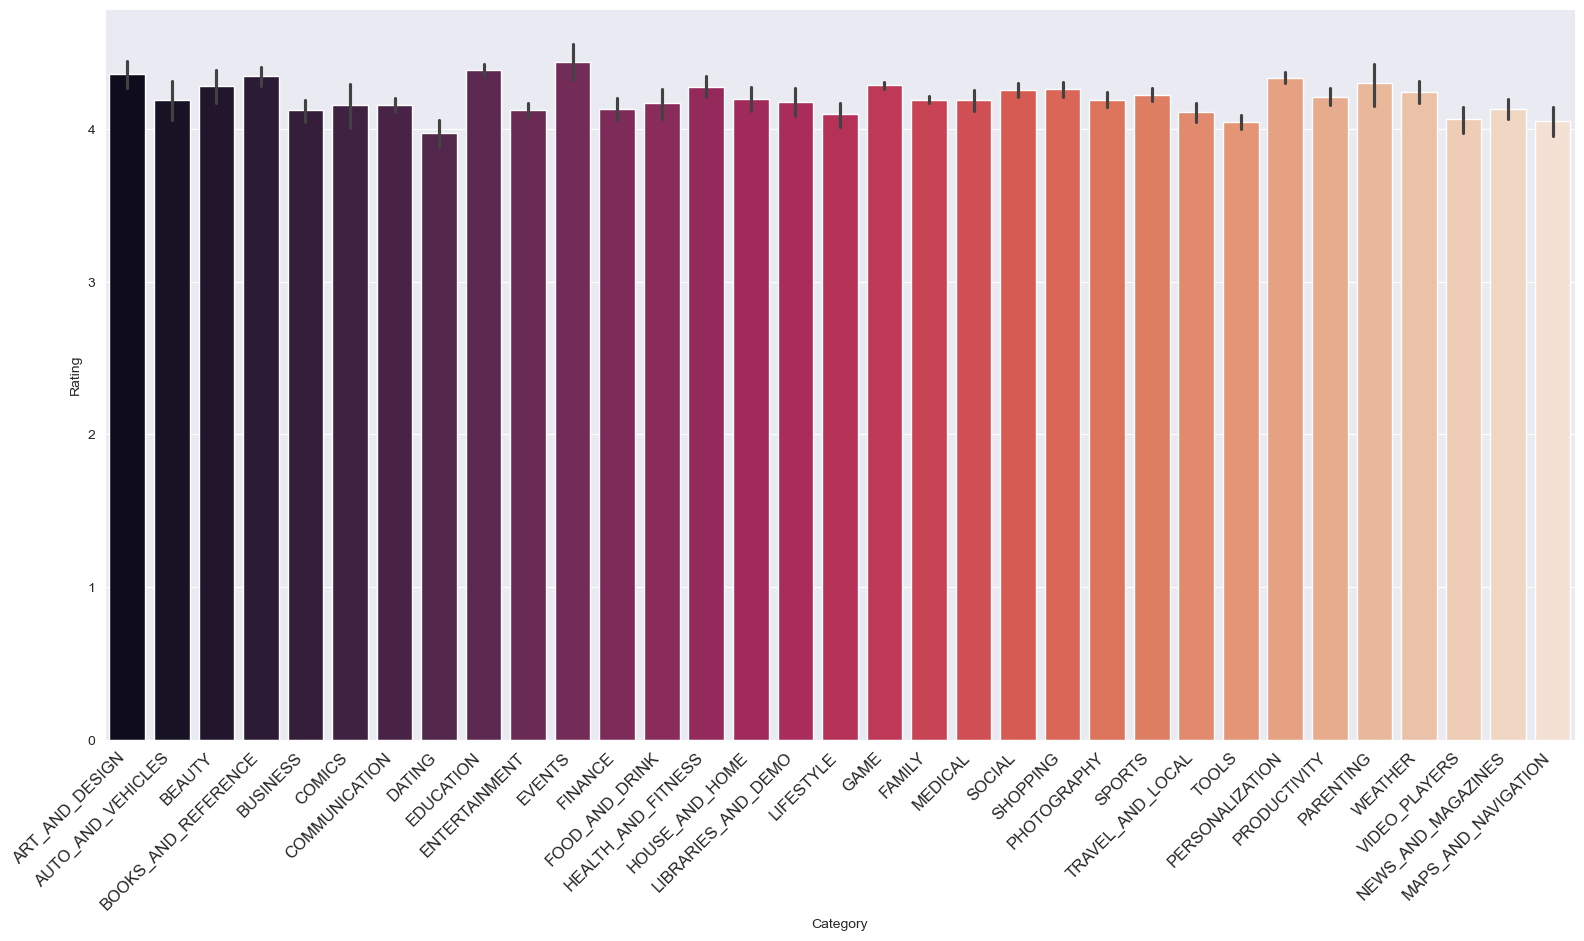

In [21]:
g = sns.catplot(data=data,x="Category",y="Rating", estimator='mean', kind="bar",palette="rocket",height=8, aspect=2 )
g.set_xticklabels(rotation=45, ha='right', fontsize=12)
plt.show()

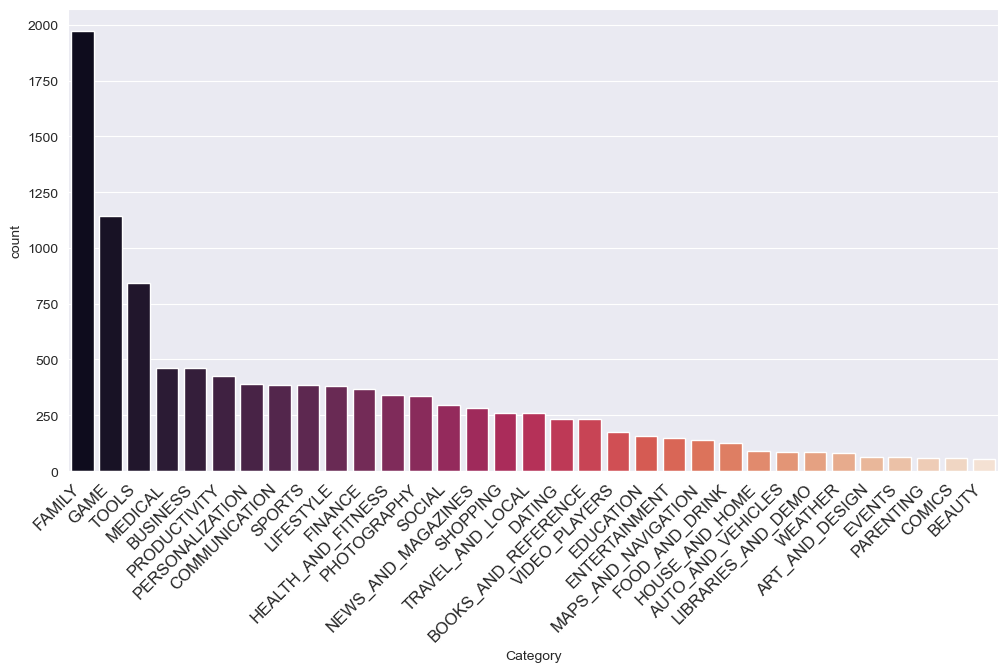

In [22]:
plt.figure(figsize=(12,6))
sns.countplot(data=data, x="Category", order=data['Category'].value_counts().index,palette="rocket")
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.show()

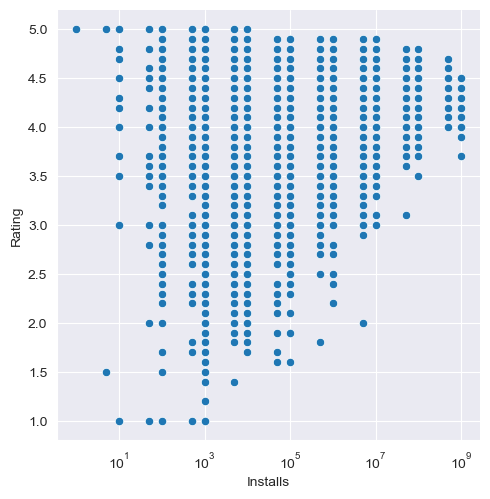

In [23]:
sns.relplot(data=data, x="Installs", y="Rating",kind="scatter")
plt.xscale("log")  
plt.show()

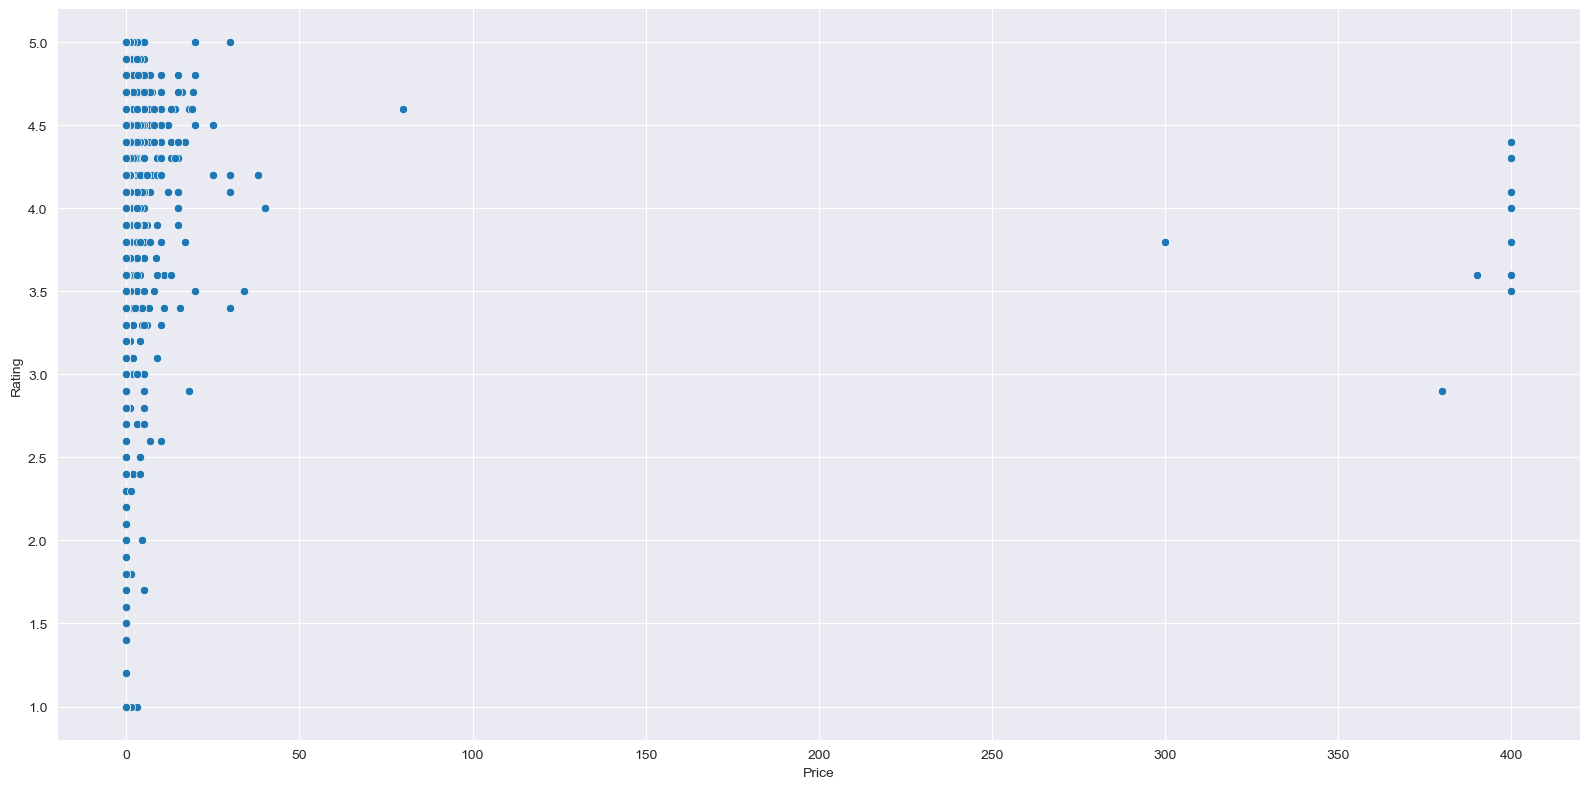

In [24]:
sns.relplot(data=data, x="Price", y="Rating",kind="scatter",height=8, aspect=2)
plt.xscale("linear")  
plt.show()

<Axes: >

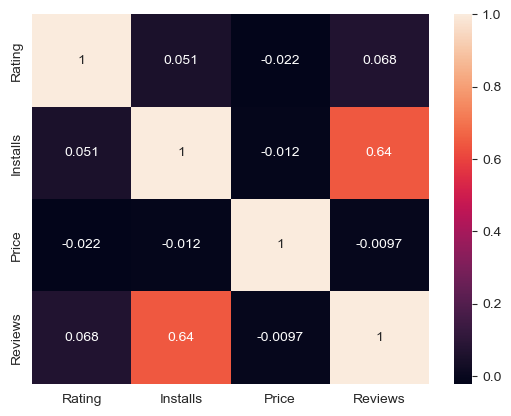

In [25]:
sns.heatmap(data[['Rating','Installs','Price','Reviews']].corr(), annot=True)

## Send us the Result (Maktabkhoone)